# GAN Evaluation — All Runs

Evaluates all trained runs and saves plots to each run's artifact folder.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path("..")
sys.path.insert(0, str(REPO_ROOT))

from FamaFrenchModel.tcn_marketgan_model import (
    MarketGANConfig,
    prepare_marketgan_data,
    MarketGANSequenceDataset,
    MarketGenerator,
    MarketCritic,
    MarketGANTrainer,
)

ARTIFACT_ROOT = REPO_ROOT / "artifacts" / "marketgan_tcn"
N_SAMPLES     = 50
N_BOOTSTRAP   = 500

In [2]:
# ── Run configurations ────────────────────────────────────────────────────────
# train_fraction / val_fraction control which windows belong to each split.
# For runs with no test set, set test=False.
RUN_CONFIGS = [
    {
        "run_name":       "marketgan_famafrench_20assets_run1",
        "label":          "20-asset Run — FF3 + Welch-Goyal (200 epochs)",
        "checkpoint":     "latest.pt",
        "train_fraction": 0.875,
        "val_fraction":   0.125,
        "has_test":       False,         # no fine-tuning → val is clean OOS
    },
    {
        "run_name":       "marketgan_famafrench_50assets_run1",
        "label":          "50-asset Run — FF3 + Welch-Goyal (300 epochs)",
        "checkpoint":     "best.pt",     # best val_vol_gap checkpoint; switch to fine_tuned.pt after fine-tuning
        "train_fraction": 0.75,
        "val_fraction":   0.125,
        "has_test":       True,
    },
]

for rc in RUN_CONFIGS:
    cp = ARTIFACT_ROOT / rc["run_name"] / "checkpoints" / rc["checkpoint"]
    print(f"{rc['label']:60s}  checkpoint={'✓' if cp.exists() else '✗ MISSING'}")

20-asset Run — FF3 + Welch-Goyal (200 epochs)                 checkpoint=✓
50-asset Run — FF3 + Welch-Goyal (300 epochs)                 checkpoint=✓


In [3]:
import tempfile, os


def _prepared_batch_from_slice(prepared_data, selection, device):
    return {
        "covariates": torch.tensor(prepared_data.covariates[selection], dtype=torch.float32).unsqueeze(0).to(device),
        "factors": torch.tensor(prepared_data.factors[selection], dtype=torch.float32).unsqueeze(0).to(device),
        "real_returns": torch.tensor(prepared_data.real_returns[selection], dtype=torch.float32).unsqueeze(0).to(device),
        "alpha_hat": torch.tensor(prepared_data.alpha_hat[selection], dtype=torch.float32).unsqueeze(0).to(device),
        "beta_hat": torch.tensor(prepared_data.beta_hat[selection], dtype=torch.float32).unsqueeze(0).to(device),
        "sigma_hat": torch.tensor(prepared_data.sigma_hat[selection], dtype=torch.float32).unsqueeze(0).to(device),
    }


def evaluate_run(rc, artifact_root, n_samples=50, n_bootstrap=500, split="val"):
    """
    split="train" -> training windows only (in-sample reference)
    split="val"   -> validation windows (used for checkpoint selection + fine-tuning)
    split="test"  -> held-out test windows (final honest eval, only for runs with has_test=True)
    split="all"   -> full dataset (biased, avoid)

    The aggregate diagnostics below still sample several model windows. For rolling
    correlation plots, this function also returns one continuous trajectory so the
    notebook does not concatenate heavily overlapping windows into a fake timeline.
    """
    run_name   = rc["run_name"]
    label      = rc["label"]
    out_dir    = artifact_root / run_name
    checkpoint = artifact_root / run_name / "checkpoints" / rc["checkpoint"]

    if not checkpoint.exists():
        print(f"Skipping {run_name} - {rc['checkpoint']} not found")
        return None

    if split == "test" and not rc.get("has_test", False):
        print(f"Skipping test split for {run_name} - no held-out test set for this run")
        return None

    # -- Peek at checkpoint to get asset universe --------------------------------
    ckpt = torch.load(checkpoint, map_location="cpu", weights_only=False)
    ckpt_asset_columns = ckpt.get("asset_columns", None)

    config = MarketGANConfig(batch_size=128, target_horizon=252 * 4)

    # If checkpoint has fewer assets than current CSV, filter to match
    tmp_path = None
    if ckpt_asset_columns is not None:
        returns_df = pd.read_csv(config.returns_path, index_col="Date", parse_dates=True)
        if set(ckpt_asset_columns) != set(returns_df.columns):
            available = [c for c in ckpt_asset_columns if c in returns_df.columns]
            missing   = set(ckpt_asset_columns) - set(returns_df.columns)
            if missing:
                print(f"  Warning: {missing} not in current returns CSV - skipping those assets")
            filtered = returns_df[available].copy()
            filtered.index.name = "Date"
            tmp = tempfile.NamedTemporaryFile(suffix=".csv", delete=False, mode="w")
            filtered.to_csv(tmp.name)
            tmp.close()
            tmp_path = tmp.name
            config.returns_path = Path(tmp_path)
            print(f"  Filtered returns CSV to {len(available)} assets matching checkpoint")

    prepared_data = prepare_marketgan_data(config=config, factor_frame=None)
    dataset = MarketGANSequenceDataset(prepared_data, sequence_length=config.total_sequence_length)

    generator = MarketGenerator(prepared_data.dimensions, config).to(config.device)
    generator.load_state_dict(ckpt["generator_state_dict"])
    generator.eval()

    # -- Select window indices based on split -----------------------------------
    total     = len(dataset)
    train_end = int(total * rc["train_fraction"])
    val_end   = int(total * (rc["train_fraction"] + rc["val_fraction"]))

    if split == "train":
        idx_range   = (0, train_end - 1)
        split_label = f"Train windows (0-{train_end-1})"
    elif split == "val":
        idx_range   = (train_end, val_end - 1)
        split_label = f"Val windows ({train_end}-{val_end-1})"
    elif split == "test":
        idx_range   = (val_end, total - 1)
        split_label = f"Test windows ({val_end}-{total-1})  held-out"
    else:
        idx_range   = (0, total - 1)
        split_label = f"All windows (0-{total-1})"

    if idx_range[1] < idx_range[0]:
        print(f"Skipping {run_name} {split} - empty split")
        return None

    indices = np.linspace(idx_range[0], idx_range[1], n_samples, dtype=int)

    print(f"\n{'='*60}")
    print(f"{label}  (checkpoint epoch: {ckpt['epoch']})")
    print(f"  Split: {split_label}  ->  {len(indices)} sampled windows")
    print(f"  Assets: {prepared_data.dimensions.num_assets}  "
          f"Factors: {prepared_data.factor_columns}  "
          f"Covariates: {prepared_data.covariate_columns}")

    # -- Generate sampled windows for aggregate diagnostics ----------------------
    generated_list, real_list = [], []
    with torch.no_grad():
        for idx in indices:
            sample = dataset[int(idx)]
            batch  = {k: v.unsqueeze(0).to(config.device) for k, v in sample.items()}
            out    = generator(
                covariates=batch["covariates"],
                factor_returns=batch["factors"],
                alpha_hat=batch["alpha_hat"],
                beta_hat=batch["beta_hat"],
                sigma_hat=batch["sigma_hat"],
                trim_output=True,
            )
            generated_list.append(out["generated_returns_trimmed"][0].cpu().numpy())
            real_list.append(batch["real_returns"][0, config.warmup_period:, :].cpu().numpy())

    gen_df  = pd.DataFrame(np.concatenate(generated_list, axis=0), columns=prepared_data.asset_columns)
    real_df = pd.DataFrame(np.concatenate(real_list,      axis=0), columns=prepared_data.asset_columns)

    # -- Generate one continuous path for rolling-correlation plots --------------
    # The old rolling plot used gen_df/real_df above, which stitches together 50
    # highly overlapping 1008-day windows. That creates periodic artifacts. Here
    # we evaluate the same split range as a single contiguous tensor instead.
    continuous_start = idx_range[0]
    continuous_end   = min(idx_range[1] + config.total_sequence_length, len(prepared_data))
    continuous_len   = continuous_end - continuous_start
    gen_cont_df = None
    real_cont_df = None

    if continuous_len > config.warmup_period:
        cont_selection = slice(continuous_start, continuous_end)
        cont_batch = _prepared_batch_from_slice(prepared_data, cont_selection, config.device)
        with torch.no_grad():
            cont_out = generator(
                covariates=cont_batch["covariates"],
                factor_returns=cont_batch["factors"],
                alpha_hat=cont_batch["alpha_hat"],
                beta_hat=cont_batch["beta_hat"],
                sigma_hat=cont_batch["sigma_hat"],
                trim_output=True,
            )

        cont_dates = prepared_data.target_dates[continuous_start + config.warmup_period : continuous_end]
        gen_cont_df = pd.DataFrame(
            cont_out["generated_returns_trimmed"][0].cpu().numpy(),
            index=cont_dates,
            columns=prepared_data.asset_columns,
        )
        real_cont_df = pd.DataFrame(
            cont_batch["real_returns"][0, config.warmup_period:, :].cpu().numpy(),
            index=cont_dates,
            columns=prepared_data.asset_columns,
        )
        gen_cont_df.index.name = "Date"
        real_cont_df.index.name = "Date"
        if len(gen_cont_df) > 0:
            print(
                "  Continuous rolling path: "
                f"{len(gen_cont_df)} days "
                f"({gen_cont_df.index[0].date()} -> {gen_cont_df.index[-1].date()})"
            )
    else:
        print("  Continuous rolling path skipped - split is shorter than warmup period")

    # Cleanup temp file if created
    if tmp_path and os.path.exists(tmp_path):
        os.unlink(tmp_path)

    out_dir.mkdir(parents=True, exist_ok=True)
    gen_df.to_csv(out_dir / f"generated_returns_{split}.csv", index=False)
    if gen_cont_df is not None:
        gen_cont_df.to_csv(out_dir / f"generated_returns_{split}_continuous.csv")

    full_label = f"{label}\n[{split.upper()} SET]"

    # -- Plot 1: Center Mass - Volatility & Skewness only ------------------------
    s_real = pd.DataFrame({"std": real_df.std(), "skew": real_df.skew()})
    s_gen  = pd.DataFrame({"std": gen_df.std(),  "skew": gen_df.skew()})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Volatility: y=x reference (generated should match real)
    ax = axes[0]
    ax.scatter(s_real["std"], s_gen["std"], alpha=0.7, s=40)
    lo = min(s_real["std"].min(), s_gen["std"].min())
    hi = max(s_real["std"].max(), s_gen["std"].max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_xlabel("Real"); ax.set_ylabel("Generated")
    ax.set_title("Volatility (std)")
    ax.grid(alpha=0.3)

    # Skewness: vertical line at x=0 and horizontal line at y=0
    ax = axes[1]
    ax.scatter(s_real["skew"], s_gen["skew"], alpha=0.7, s=40)
    ax.axvline(0, color="r", linestyle="--", linewidth=1)
    ax.axhline(0, color="r", linestyle="--", linewidth=1)
    ax.set_xlabel("Real"); ax.set_ylabel("Generated")
    ax.set_title("Skewness")
    ax.grid(alpha=0.3)

    plt.suptitle(f"{full_label} - Center Mass", fontsize=12)
    plt.tight_layout()
    plt.savefig(out_dir / f"eval_center_mass_{split}.png", dpi=150)
    plt.show()

    # -- Plot 2: Left Tail Exceedance -------------------------------------------
    thresholds  = np.linspace(-0.10, -0.005, 60)
    flat_real   = real_df.values.flatten()
    flat_gen    = gen_df.values.flatten()
    real_exc    = np.array([(flat_real < t).mean() for t in thresholds])
    gen_exc     = np.array([(flat_gen  < t).mean() for t in thresholds])
    boot_curves = np.array([
        [(np.random.choice(flat_real, size=len(flat_real), replace=True) < t).mean() for t in thresholds]
        for _ in range(n_bootstrap)
    ])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, real_exc, "b-",  linewidth=2, label="Real")
    ax.plot(thresholds, gen_exc,  "r--", linewidth=2, label="Generated")
    ax.fill_between(thresholds,
                    np.percentile(boot_curves, 2.5,  axis=0),
                    np.percentile(boot_curves, 97.5, axis=0),
                    alpha=0.2, color="blue", label="Real 95% CI (bootstrap)")
    ax.set_xlabel("Return threshold"); ax.set_ylabel("Exceedance probability")
    ax.set_title(f"{full_label} - Left Tail Exceedance")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"eval_left_tail_{split}.png", dpi=150)
    plt.show()

    # -- Plot 3: Correlation Matrix ---------------------------------------------
    corr_real = real_df.corr()
    corr_gen  = gen_df.corr()
    diff      = corr_gen - corr_real
    frob      = np.linalg.norm(diff.values, "fro")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, mat, title in zip(axes,
                               [corr_real, corr_gen, diff],
                               ["Real", "Generated", "Difference (Gen - Real)"]):
        vmin, vmax = (-1, 1) if "Diff" not in title else (-0.5, 0.5)
        im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="RdBu_r")
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax)
    plt.suptitle(f"{full_label} - Correlation Matrix  (Frobenius diff: {frob:.3f})", fontsize=12)
    plt.tight_layout()
    plt.savefig(out_dir / f"eval_correlation_{split}.png", dpi=150)
    plt.show()

    # -- Plot 4: Per-Asset Volatility -------------------------------------------
    vol_real  = real_df.std()
    vol_gen   = gen_df.std()
    boot_vols = pd.DataFrame([
        real_df.iloc[np.random.choice(len(real_df), size=len(real_df), replace=True)].std()
        for _ in range(n_bootstrap)
    ])

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(prepared_data.asset_columns))
    ax.bar(x - 0.2, vol_real, 0.35, label="Real",      color="steelblue", alpha=0.8)
    ax.bar(x + 0.2, vol_gen,  0.35, label="Generated", color="tomato",    alpha=0.8)
    ax.errorbar(x - 0.2, vol_real,
                yerr=[vol_real - boot_vols.quantile(0.025), boot_vols.quantile(0.975) - vol_real],
                fmt="none", color="black", capsize=3, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(prepared_data.asset_columns, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Daily return std")
    ax.set_title(f"{full_label} - Per-Asset Volatility (with 95% CI)")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"eval_volatility_{split}.png", dpi=150)
    plt.show()

    print(f"\n  Frobenius norm (corr diff): {frob:.4f}")
    print(f"  Median vol ratio (gen/real): {(vol_gen / vol_real).median():.4f}")
    print(f"  Saved plots -> {out_dir}")
    return {
        "gen_df": gen_df,
        "real_df": real_df,
        "gen_cont_df": gen_cont_df,
        "real_cont_df": real_cont_df,
        "frob": frob,
        "vol_real": vol_real,
        "vol_gen": vol_gen,
        "sample_indices": indices,
        "idx_range": idx_range,
        "target_horizon": config.target_horizon,
        "warmup_period": config.warmup_period,
    }



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  20-asset Run — FF3 + Welch-Goyal (200 epochs)

── TRAIN SET (in-sample reference) ───────────────────────
  Filtered returns CSV to 20 assets matching checkpoint


/opt/anaconda3/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



20-asset Run — FF3 + Welch-Goyal (200 epochs)  (checkpoint epoch: 199)
  Split: Train windows (0-1782)  ->  50 sampled windows
  Assets: 20  Factors: ['Mkt-RF', 'SMB', 'HML']  Covariates: ['tbl', 'tms', 'dfy', 'svar']
  Continuous rolling path: 2790 days (2013-11-20 -> 2024-12-20)


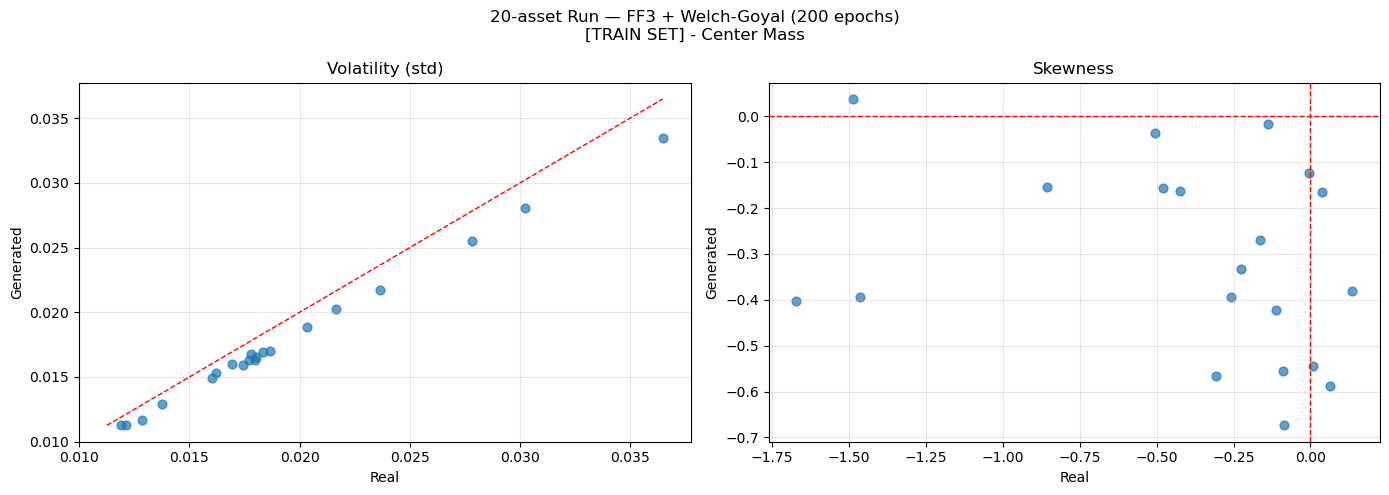

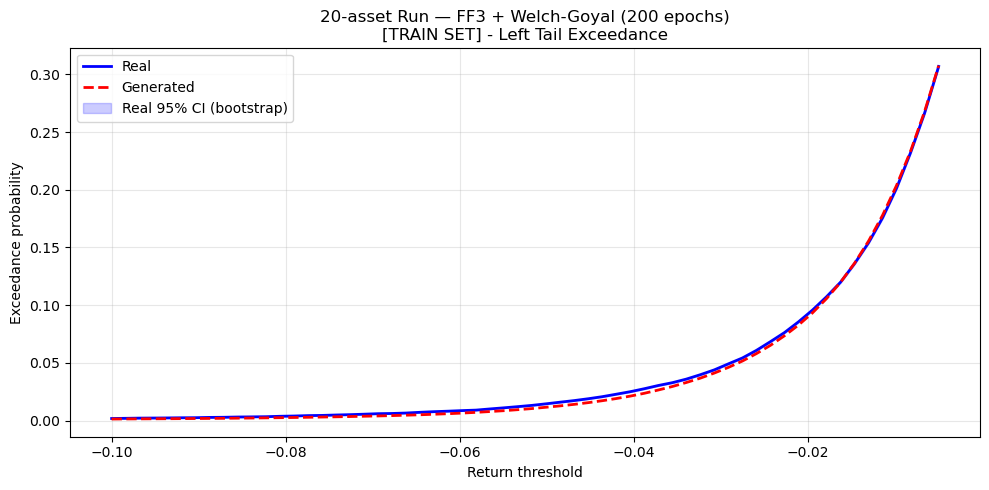

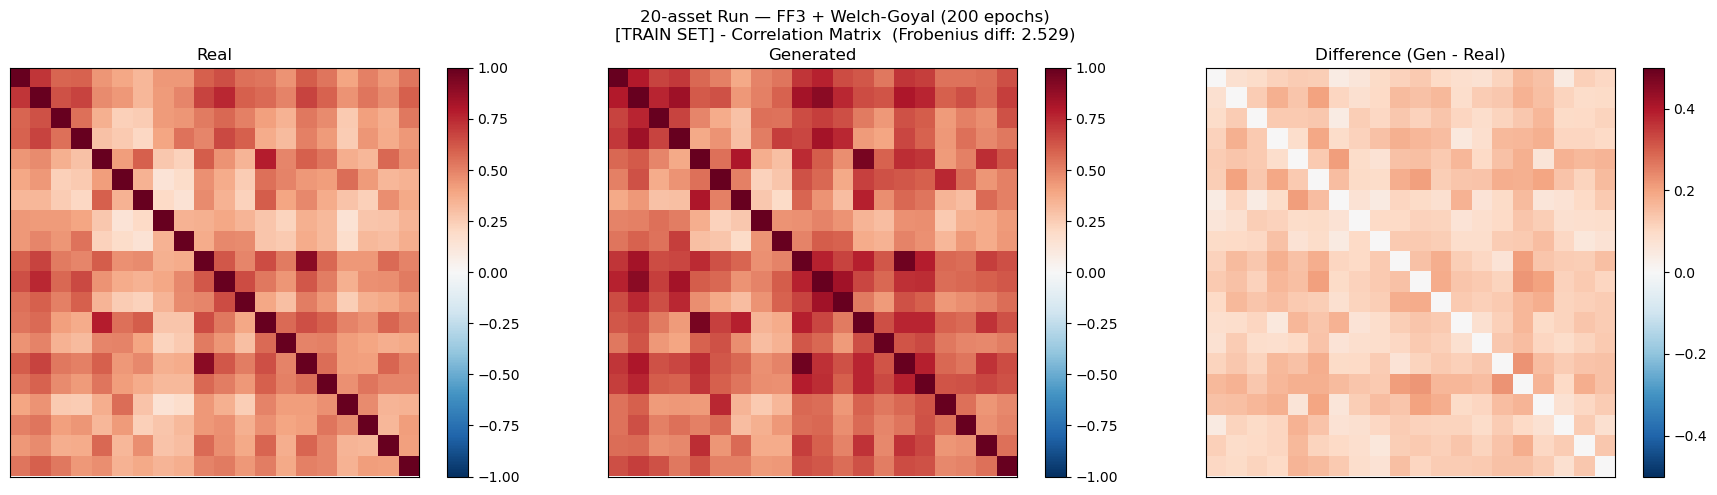

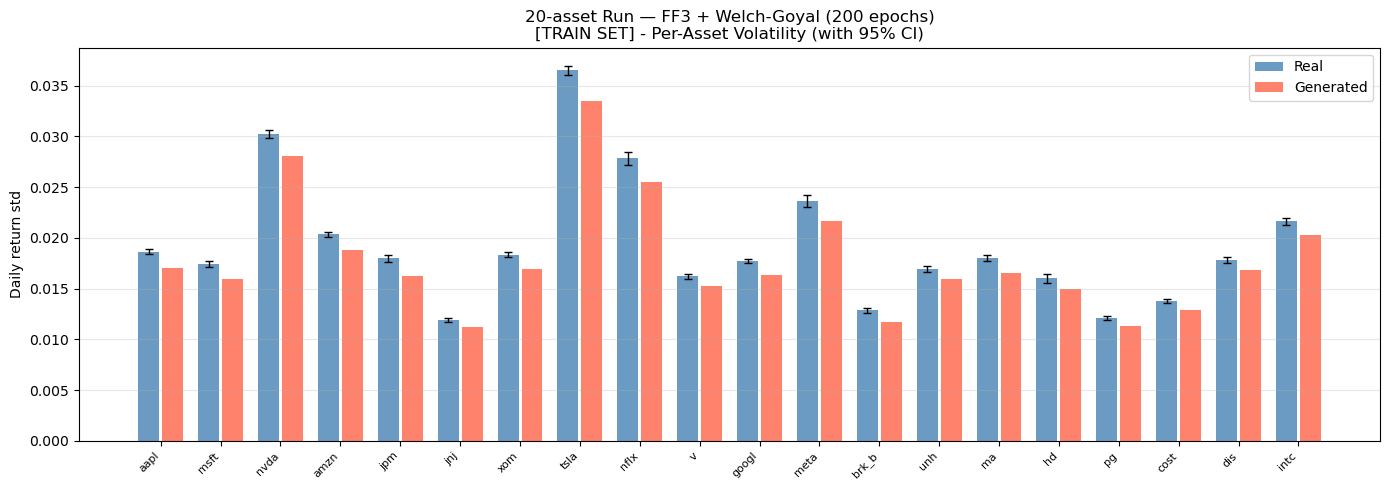


  Frobenius norm (corr diff): 2.5293
  Median vol ratio (gen/real): 0.9236
  Saved plots -> ../artifacts/marketgan_tcn/marketgan_famafrench_20assets_run1

── VAL SET (generalization) ──────────────────────────────
  Filtered returns CSV to 20 assets matching checkpoint


/opt/anaconda3/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



20-asset Run — FF3 + Welch-Goyal (200 epochs)  (checkpoint epoch: 199)
  Split: Val windows (1783-2037)  ->  50 sampled windows
  Assets: 20  Factors: ['Mkt-RF', 'SMB', 'HML']  Covariates: ['tbl', 'tms', 'dfy', 'svar']
  Continuous rolling path: 1262 days (2020-12-21 -> 2025-12-30)


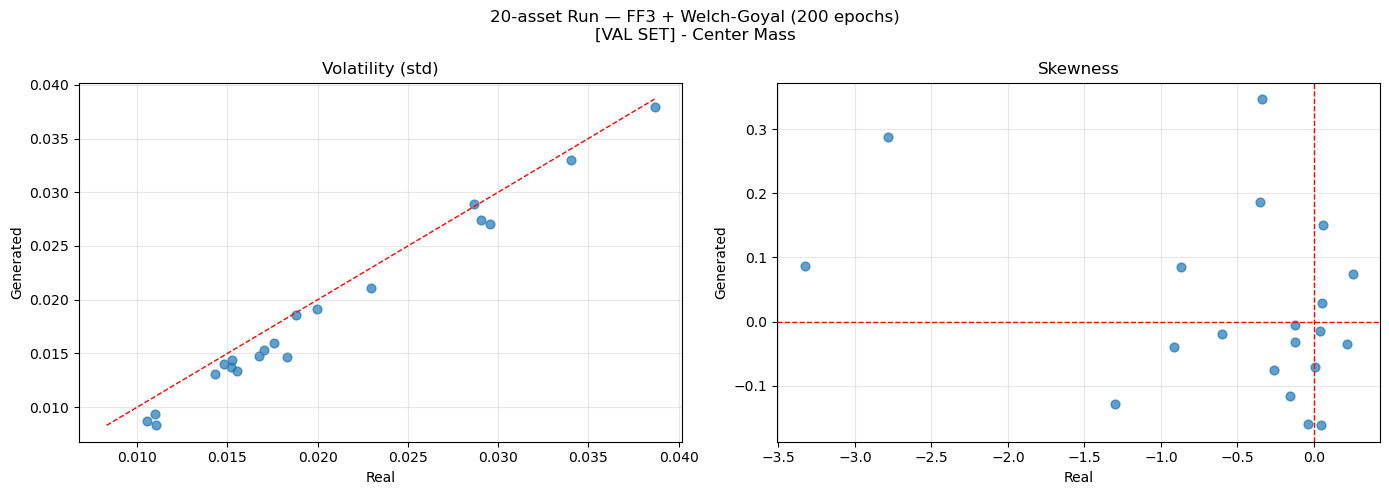

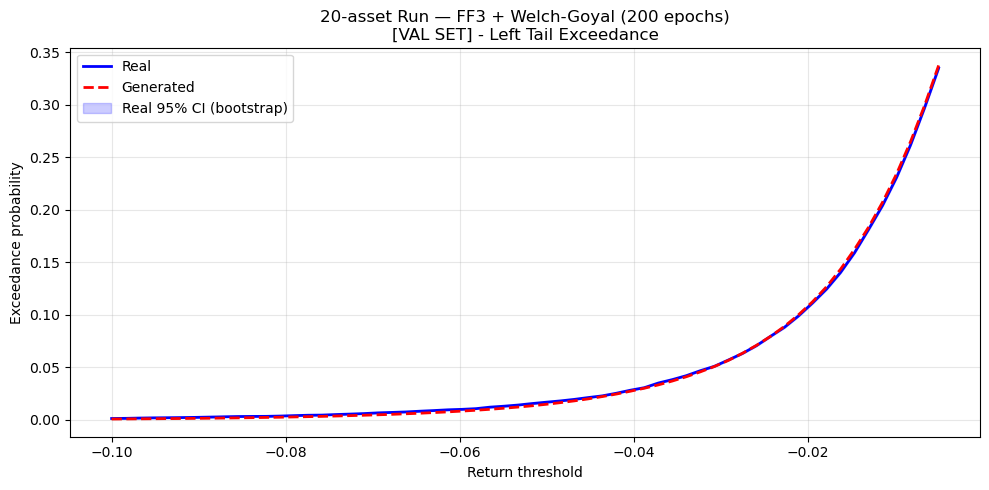

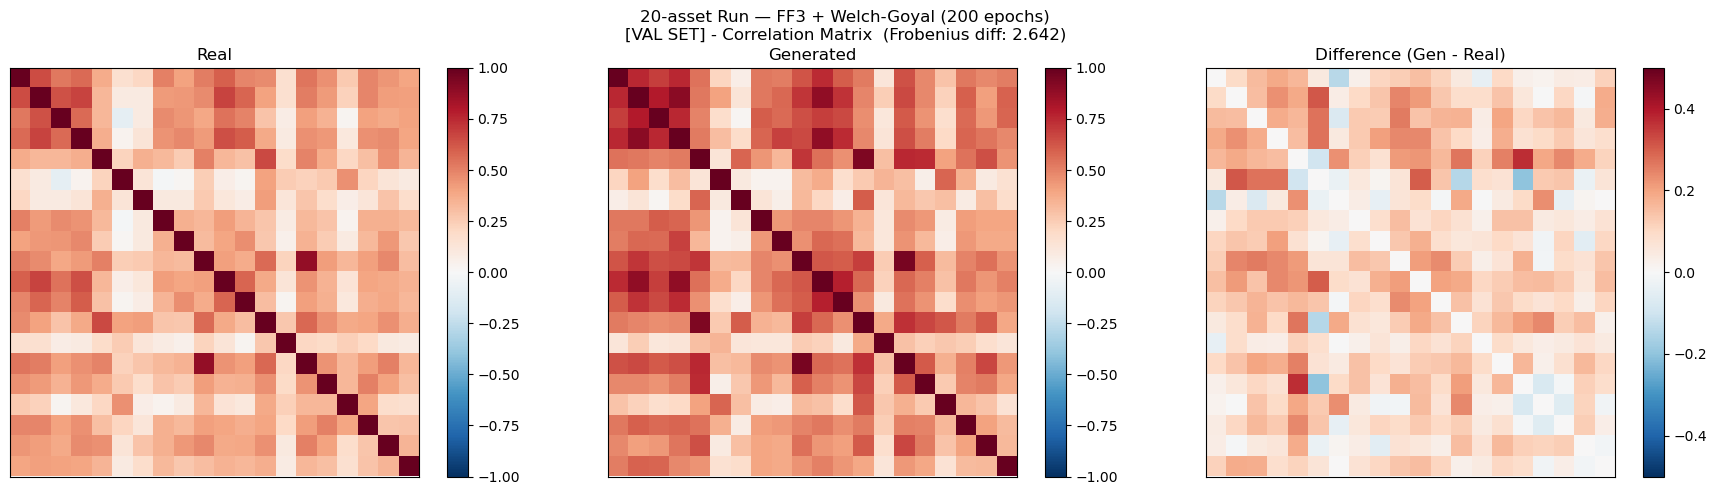

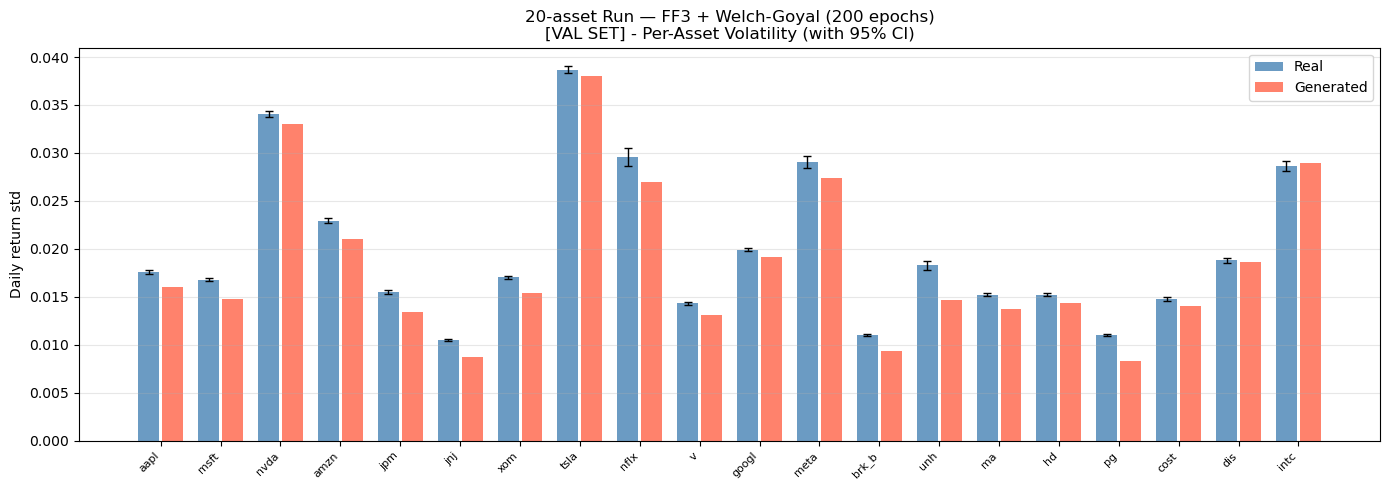


  Frobenius norm (corr diff): 2.6419
  Median vol ratio (gen/real): 0.9148
  Saved plots -> ../artifacts/marketgan_tcn/marketgan_famafrench_20assets_run1

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  50-asset Run — FF3 + Welch-Goyal (300 epochs)

── TRAIN SET (in-sample reference) ───────────────────────


/opt/anaconda3/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



50-asset Run — FF3 + Welch-Goyal (300 epochs)  (checkpoint epoch: 293)
  Split: Train windows (0-1527)  ->  50 sampled windows
  Assets: 50  Factors: ['Mkt-RF', 'SMB', 'HML']  Covariates: ['tbl', 'tms', 'dfy', 'svar']
  Continuous rolling path: 2535 days (2013-11-20 -> 2023-12-15)


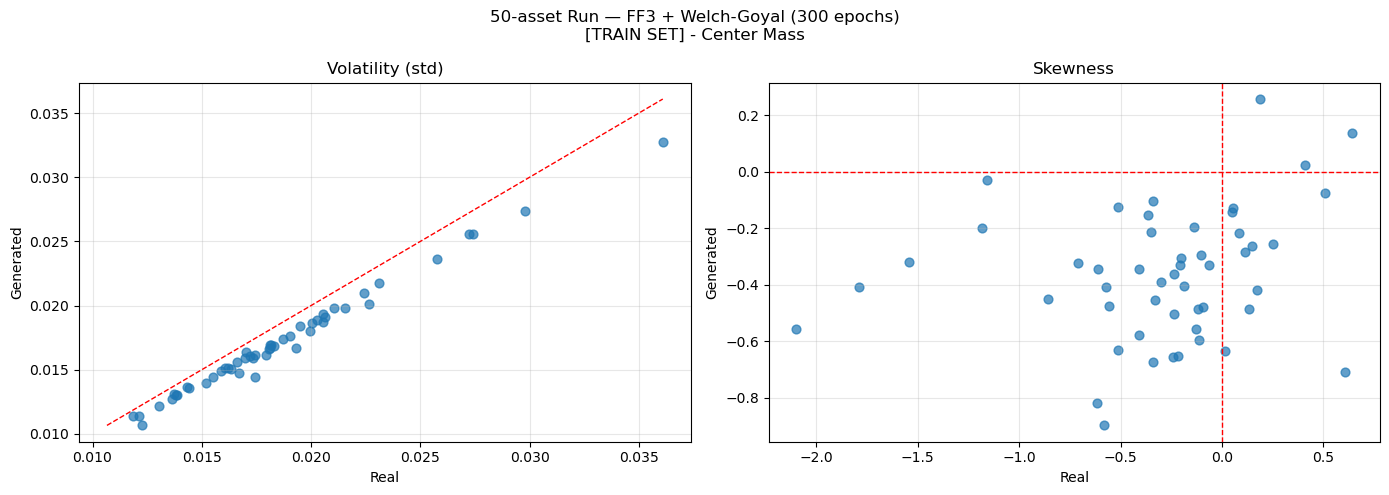

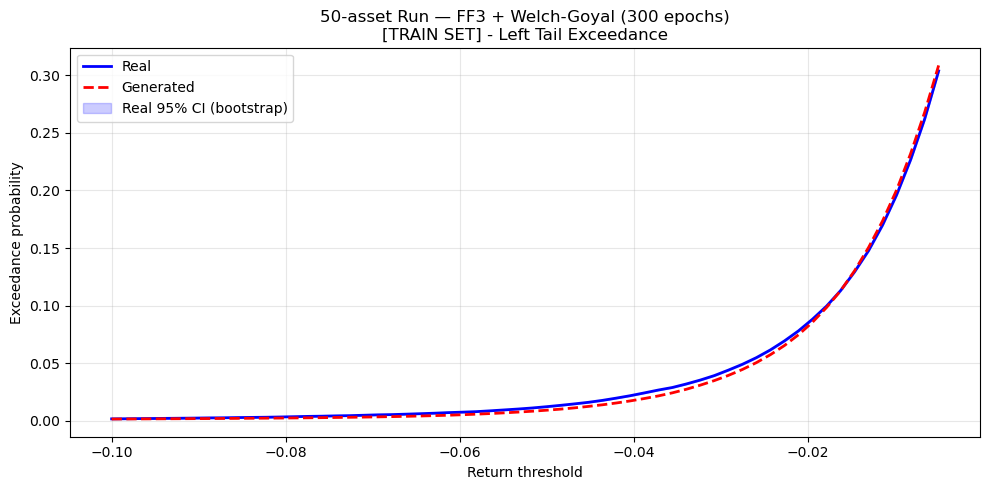

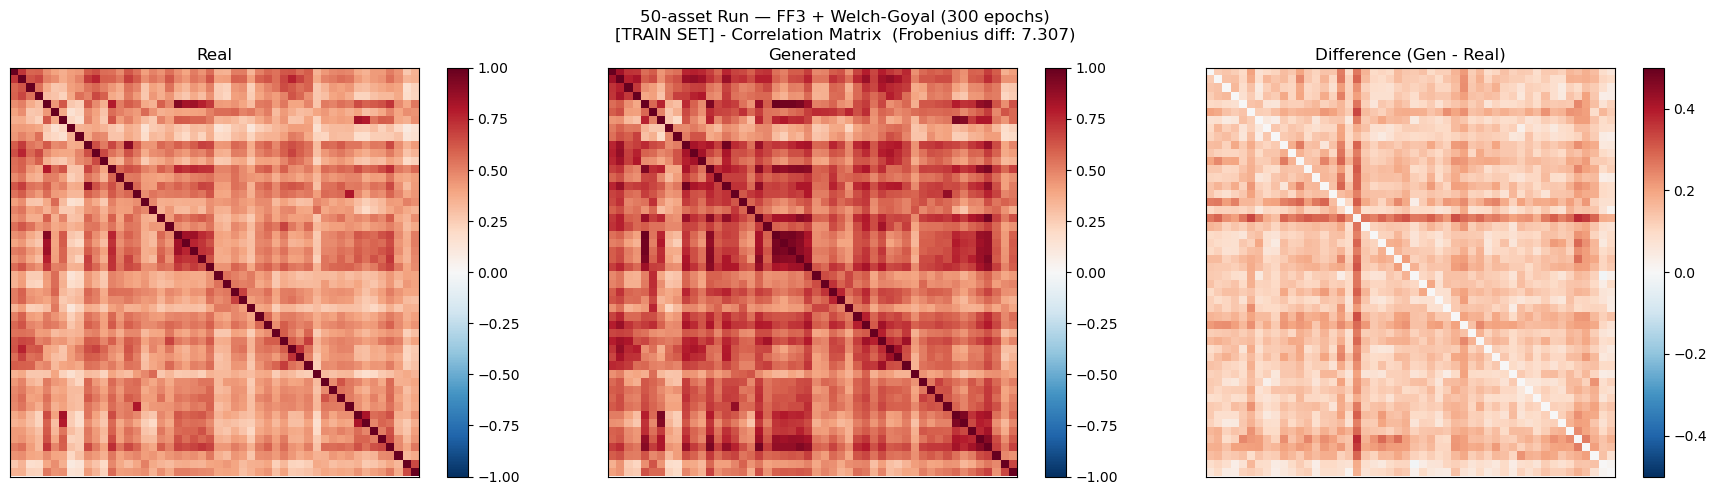

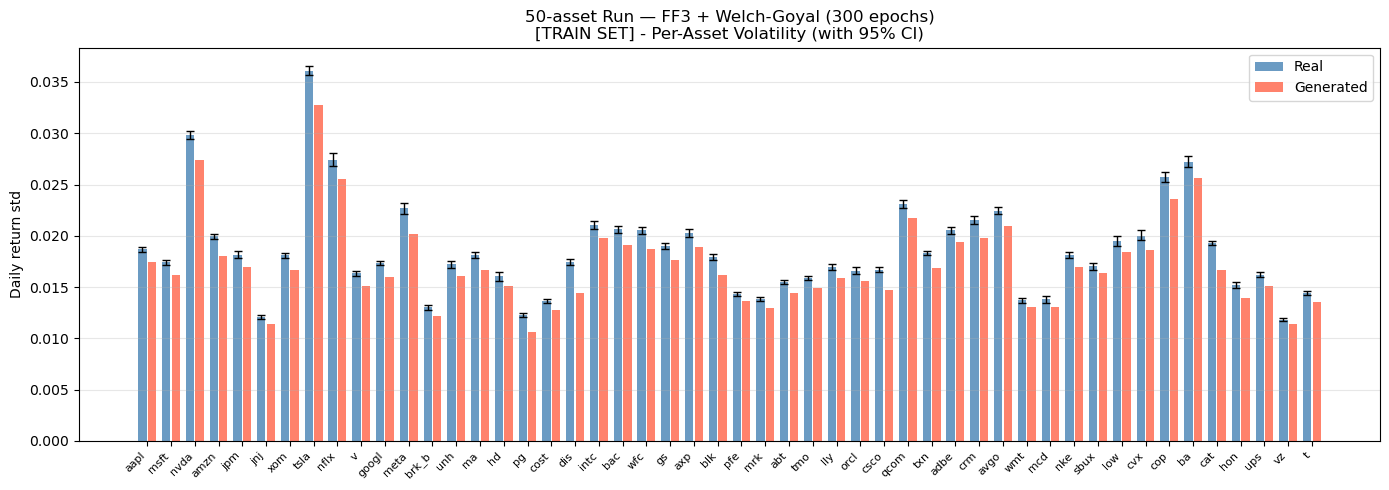


  Frobenius norm (corr diff): 7.3068
  Median vol ratio (gen/real): 0.9318
  Saved plots -> ../artifacts/marketgan_tcn/marketgan_famafrench_50assets_run1

── VAL SET (generalization) ──────────────────────────────


/opt/anaconda3/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



50-asset Run — FF3 + Welch-Goyal (300 epochs)  (checkpoint epoch: 293)
  Split: Val windows (1528-1782)  ->  50 sampled windows
  Assets: 50  Factors: ['Mkt-RF', 'SMB', 'HML']  Covariates: ['tbl', 'tms', 'dfy', 'svar']
  Continuous rolling path: 1262 days (2019-12-17 -> 2024-12-20)


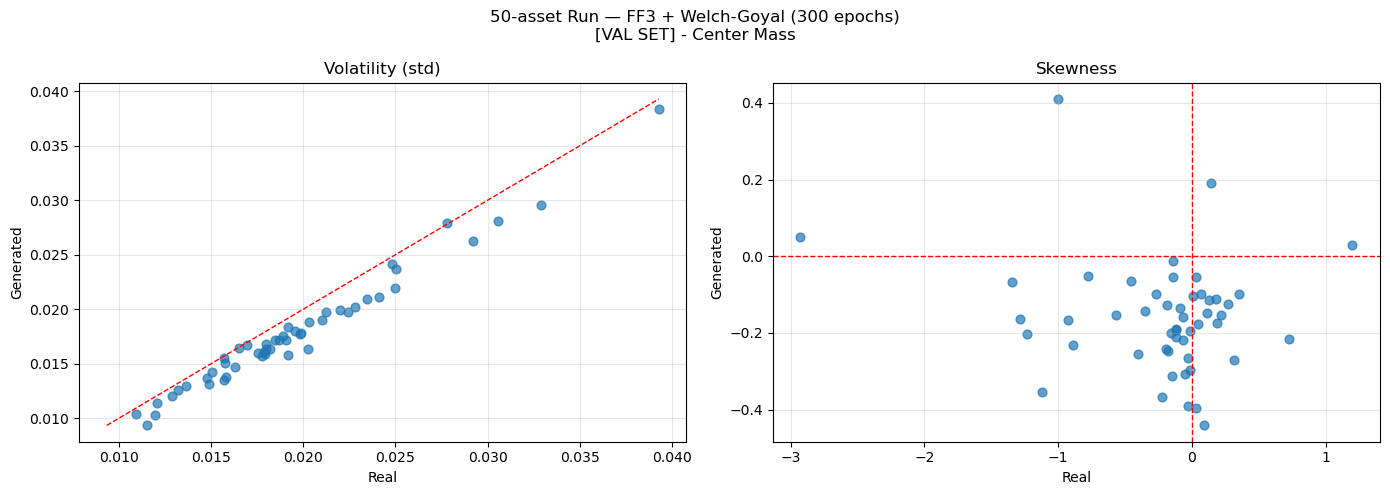

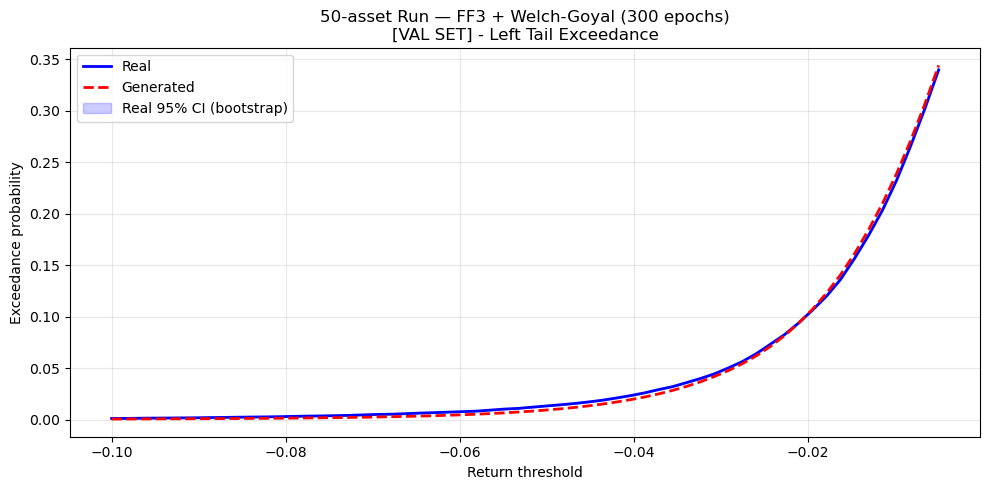

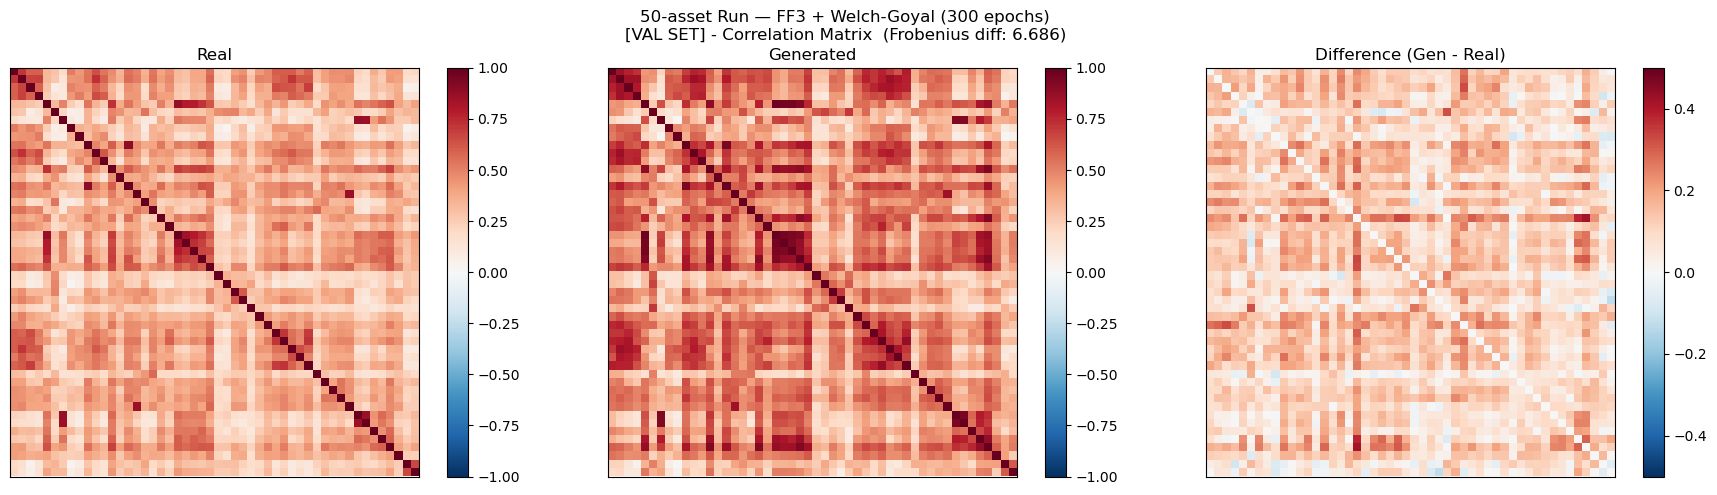

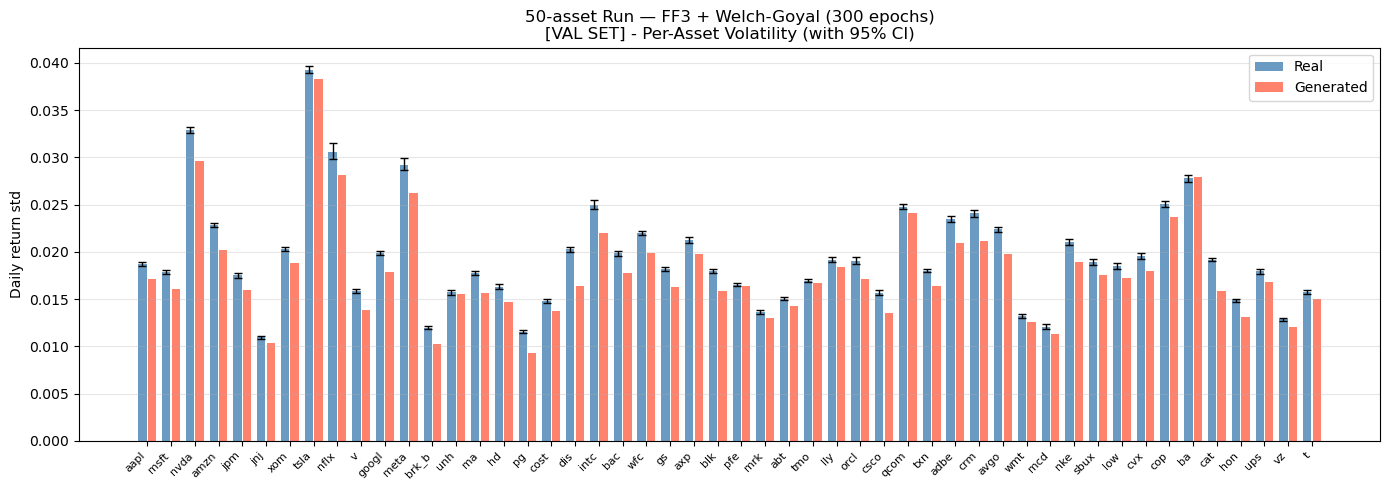


  Frobenius norm (corr diff): 6.6857
  Median vol ratio (gen/real): 0.9105
  Saved plots -> ../artifacts/marketgan_tcn/marketgan_famafrench_50assets_run1

── TEST SET (held-out, final evaluation) ─────────────────


/opt/anaconda3/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



50-asset Run — FF3 + Welch-Goyal (300 epochs)  (checkpoint epoch: 293)
  Split: Test windows (1783-2037)  held-out  ->  50 sampled windows
  Assets: 50  Factors: ['Mkt-RF', 'SMB', 'HML']  Covariates: ['tbl', 'tms', 'dfy', 'svar']
  Continuous rolling path: 1262 days (2020-12-21 -> 2025-12-30)


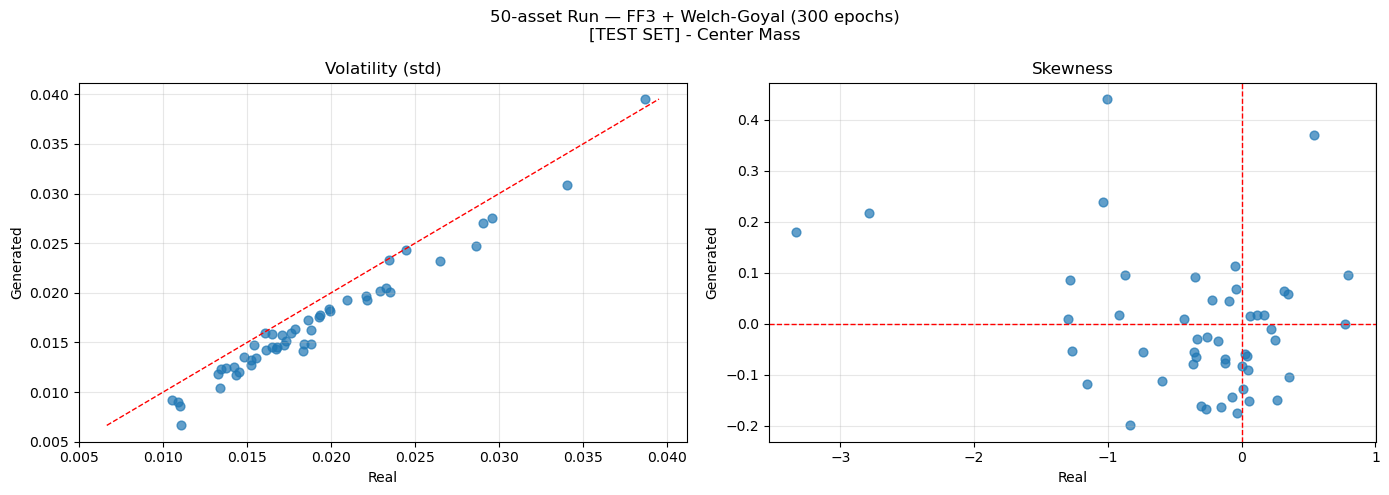

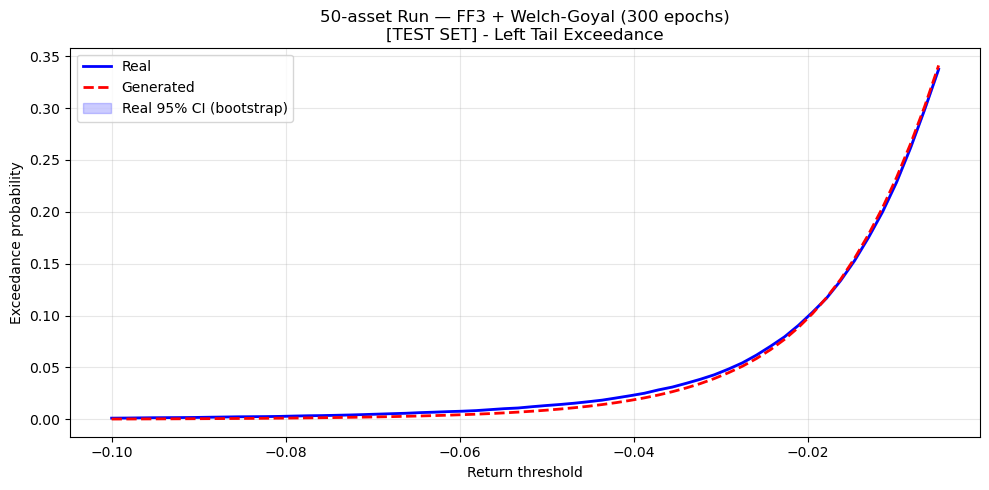

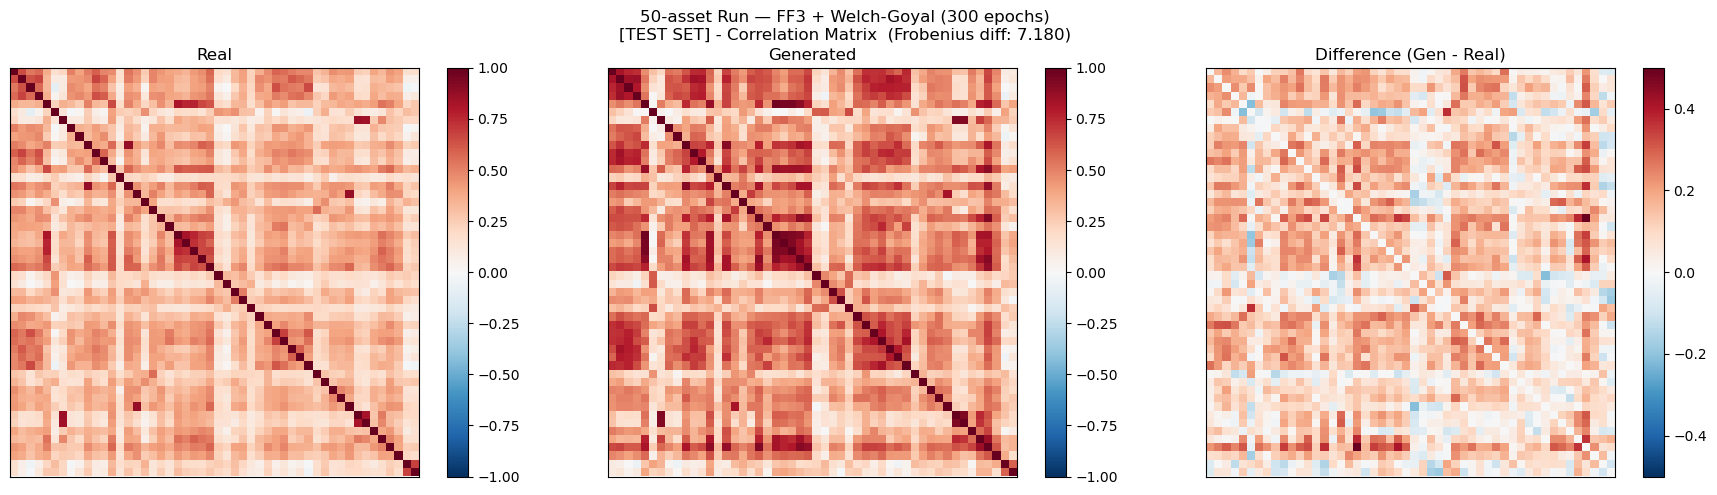

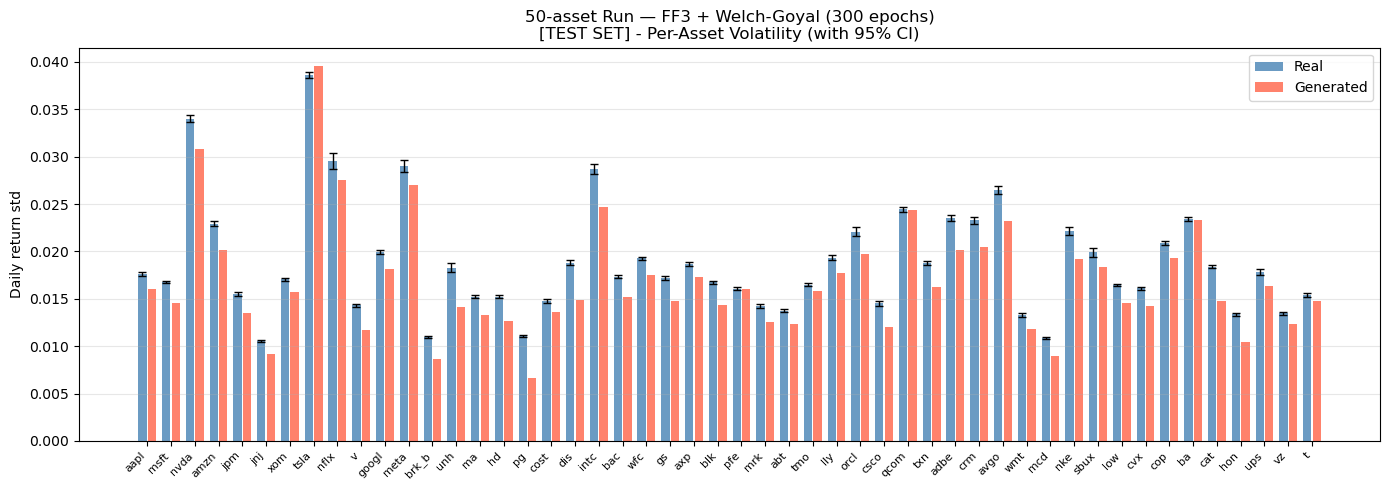


  Frobenius norm (corr diff): 7.1804
  Median vol ratio (gen/real): 0.8821
  Saved plots -> ../artifacts/marketgan_tcn/marketgan_famafrench_50assets_run1


── Summary ───────────────────────────────────────────────────────────────
Run                                       Split       Frob   Vol ratio
------------------------------------------------------------------------
20-asset Run — FF3 + Welch-Goyal (200 epochs)  train     2.5293      0.9236
20-asset Run — FF3 + Welch-Goyal (200 epochs)  val       2.6419      0.9148
50-asset Run — FF3 + Welch-Goyal (300 epochs)  train     7.3068      0.9318
50-asset Run — FF3 + Welch-Goyal (300 epochs)  val       6.6857      0.9105
50-asset Run — FF3 + Welch-Goyal (300 epochs)  test      7.1804      0.8821

Interpretation:
  val Frob ≈ train Frob  → no overfitting, model generalizes
  test Frob ≈ val Frob   → val was a fair proxy for true OOS performance


In [4]:
# ── Run evaluation ─────────────────────────────────────────────────────────────
# Splits:
#   train → in-sample reference (model saw this during training)
#   val   → model never got gradients from here, but was used for checkpoint + fine-tuning
#   test  → completely held-out, final honest evaluation (50-asset run only)

results_train = {}
results_val   = {}
results_test  = {}

for rc in RUN_CONFIGS:
    print(f"\n{'━'*60}")
    print(f"  {rc['label']}")

    print("\n── TRAIN SET (in-sample reference) ───────────────────────")
    results_train[rc["run_name"]] = evaluate_run(rc, ARTIFACT_ROOT, n_samples=N_SAMPLES, n_bootstrap=N_BOOTSTRAP, split="train")

    print("\n── VAL SET (generalization) ──────────────────────────────")
    results_val[rc["run_name"]]   = evaluate_run(rc, ARTIFACT_ROOT, n_samples=N_SAMPLES, n_bootstrap=N_BOOTSTRAP, split="val")

    if rc.get("has_test", False):
        print("\n── TEST SET (held-out, final evaluation) ─────────────────")
        results_test[rc["run_name"]] = evaluate_run(rc, ARTIFACT_ROOT, n_samples=N_SAMPLES, n_bootstrap=N_BOOTSTRAP, split="test")

# ── Summary table ──────────────────────────────────────────────────────────────
print("\n\n── Summary ───────────────────────────────────────────────────────────────")
print(f"{'Run':<40}  {'Split':<6}  {'Frob':>8}  {'Vol ratio':>10}")
print("-" * 72)
for rc in RUN_CONFIGS:
    splits = [("train", results_train), ("val", results_val)]
    if rc.get("has_test", False):
        splits.append(("test", results_test))
    for split, results in splits:
        r = results.get(rc["run_name"])
        if r is None:
            continue
        vol_ratio = (r["vol_gen"] / r["vol_real"]).median()
        print(f"{rc['label']:<40}  {split:<6}  {r['frob']:>8.4f}  {vol_ratio:>10.4f}")

print()
print("Interpretation:")
print("  val Frob ≈ train Frob  → no overfitting, model generalizes")
print("  test Frob ≈ val Frob   → val was a fair proxy for true OOS performance")

  [marketgan_famafrench_20assets_run1] Using VAL continuous path | rows: 1262 | assets: ['aapl', 'msft', 'nvda', 'amzn', 'jpm', 'jnj', 'xom', 'tsla', 'nflx', 'v', 'googl', 'meta', 'brk_b', 'unh', 'ma', 'hd', 'pg', 'cost', 'dis', 'intc'] | dates: 2020-12-21 -> 2025-12-30


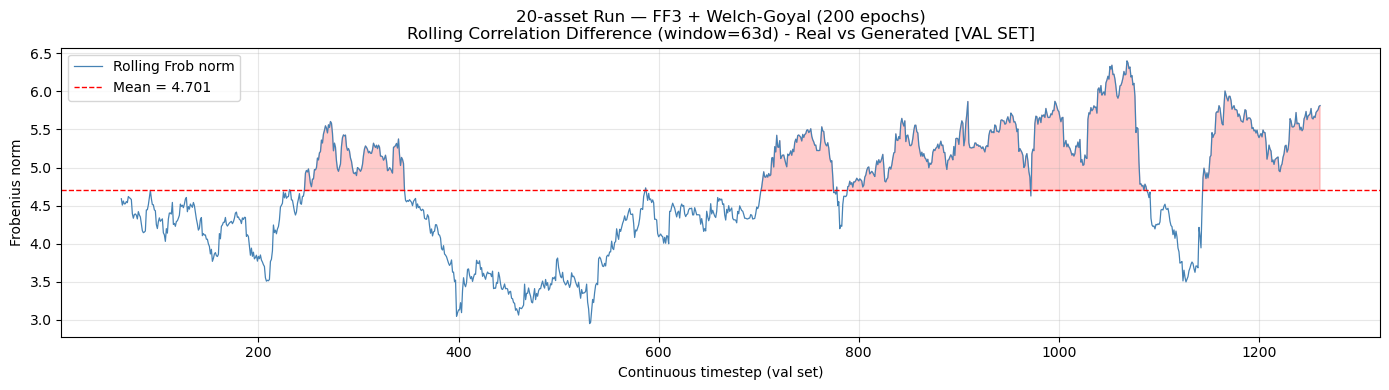

  Visa vs Mastercard                        real: 0.853  gen: 0.933  gap: 0.080
  Alphabet vs Meta                          real: 0.544  gen: 0.768  gap: 0.223
  Apple vs Microsoft                        real: 0.580  gen: 0.682  gap: 0.101


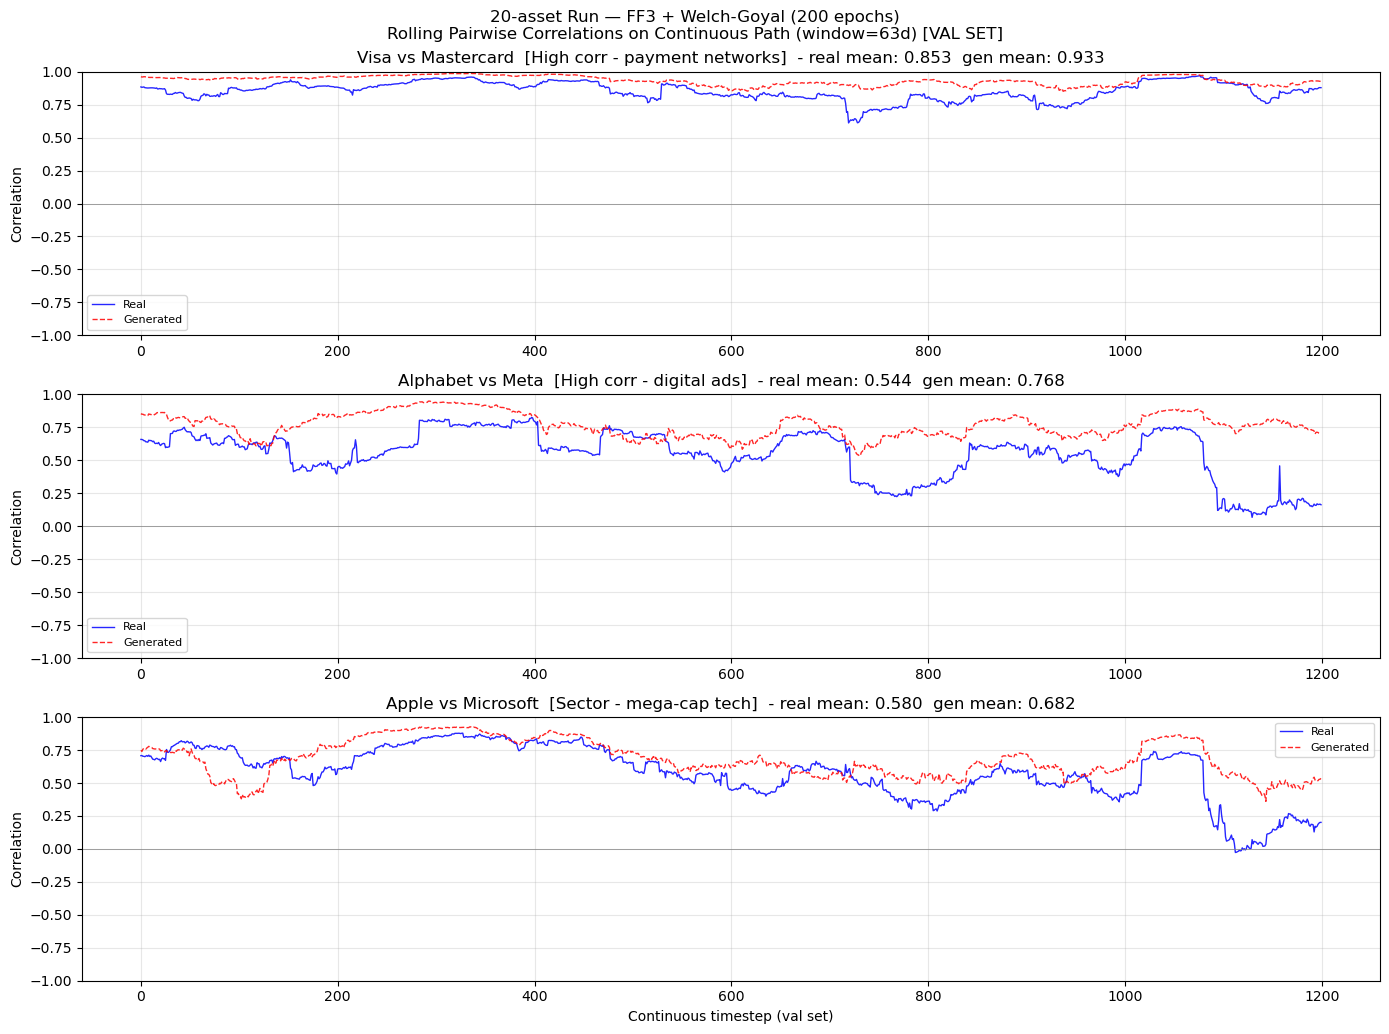


  Rolling Frob - mean: 4.7007  std: 0.7555  max: 6.3992
  Saved -> ../artifacts/marketgan_tcn/marketgan_famafrench_20assets_run1
  [marketgan_famafrench_50assets_run1] Using TEST continuous path | rows: 1262 | assets: ['aapl', 'msft', 'nvda', 'amzn', 'jpm', 'jnj', 'xom', 'tsla', 'nflx', 'v', 'googl', 'meta', 'brk_b', 'unh', 'ma', 'hd', 'pg', 'cost', 'dis', 'intc', 'bac', 'wfc', 'gs', 'axp', 'blk', 'pfe', 'mrk', 'abt', 'tmo', 'lly', 'orcl', 'csco', 'qcom', 'txn', 'adbe', 'crm', 'avgo', 'wmt', 'mcd', 'nke', 'sbux', 'low', 'cvx', 'cop', 'ba', 'cat', 'hon', 'ups', 'vz', 't'] | dates: 2020-12-21 -> 2025-12-30


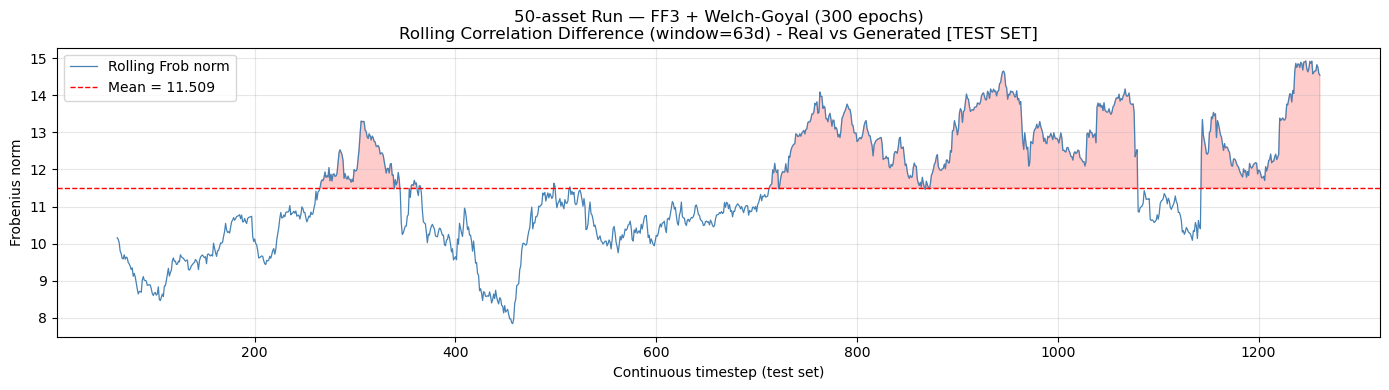

  Visa vs Mastercard                        real: 0.853  gen: 0.859  gap: 0.006
  JPMorgan vs Bank of America               real: 0.797  gen: 0.961  gap: 0.164
  Alphabet vs Meta                          real: 0.544  gen: 0.767  gap: 0.223
  ExxonMobil vs Chevron                     real: 0.836  gen: 0.906  gap: 0.070
  Apple vs Microsoft                        real: 0.580  gen: 0.783  gap: 0.203


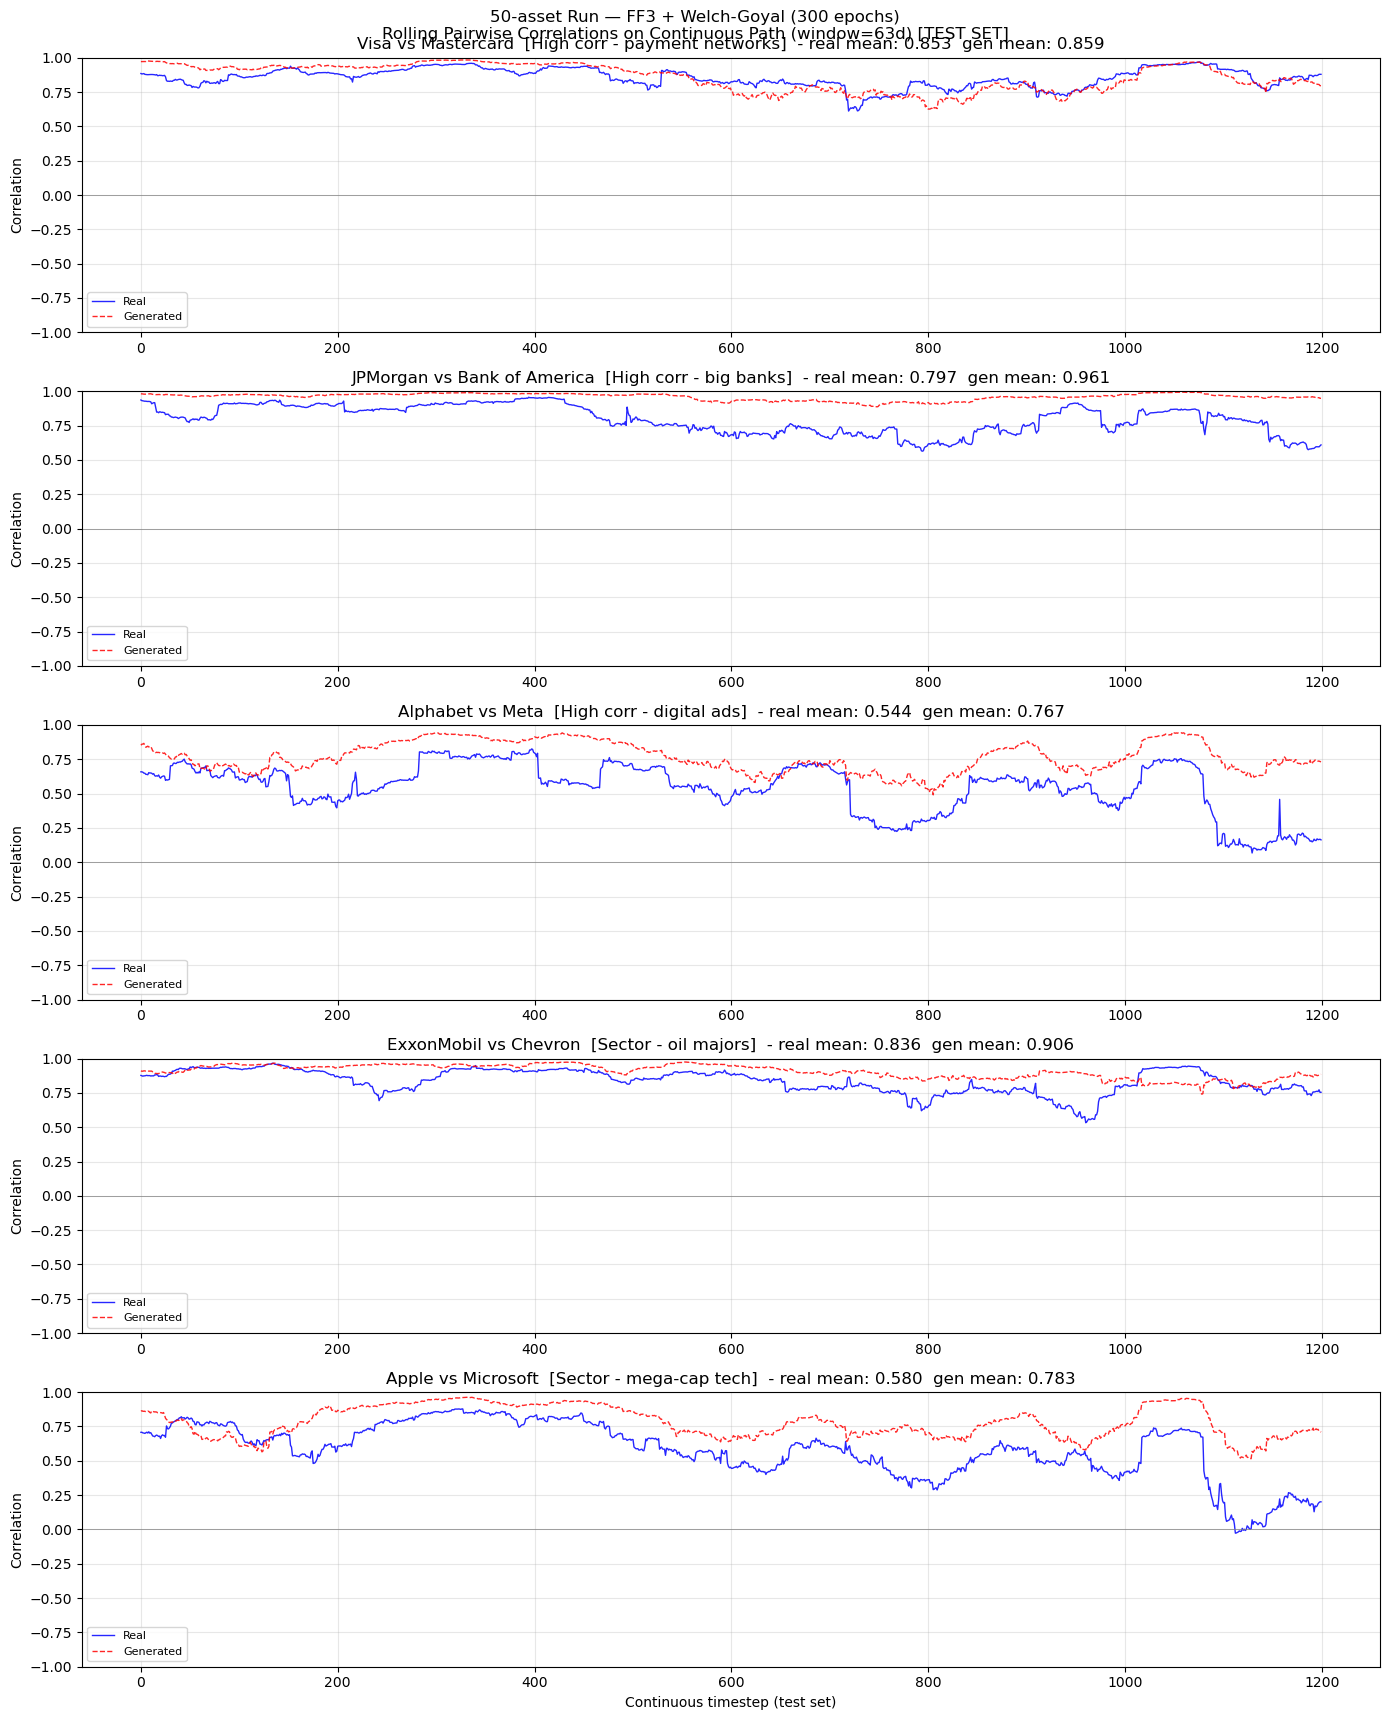


  Rolling Frob - mean: 11.5087  std: 1.5502  max: 14.9305
  Saved -> ../artifacts/marketgan_tcn/marketgan_famafrench_50assets_run1


In [5]:
def plot_rolling_correlation(rc, artifact_root, results_val, results_test, window=63):
    """
    Rolling correlation analysis.

    Uses the continuous path returned by evaluate_run. This avoids the old artifact
    where 50 overlapping 1008-day windows were concatenated into a fake timeline.
    Uses test set if available (50-asset run), otherwise val set (20-asset run).
    """
    run_name = rc["run_name"]
    label    = rc["label"]
    out_dir  = artifact_root / run_name

    # Use test if available (clean OOS), otherwise val
    if rc.get("has_test", False) and results_test.get(run_name) is not None:
        r          = results_test[run_name]
        split_used = "TEST"
    else:
        r          = results_val.get(run_name)
        split_used = "VAL"

    if r is None:
        print(f"Skipping {run_name} - no results available")
        return

    if r.get("real_cont_df") is not None and r.get("gen_cont_df") is not None:
        real_df = r["real_cont_df"].copy()
        gen_df  = r["gen_cont_df"].copy()
        timeline_note = "continuous path"
    else:
        real_df = r["real_df"].reset_index(drop=True)
        gen_df  = r["gen_df"].reset_index(drop=True)
        timeline_note = "sampled-window fallback"

    T = len(real_df)
    if T <= window:
        print(f"Skipping {run_name} - rolling window {window} exceeds available path length {T}")
        return

    if isinstance(real_df.index, pd.DatetimeIndex) and len(real_df) > 0:
        date_note = f" | dates: {real_df.index[0].date()} -> {real_df.index[-1].date()}"
    else:
        date_note = ""

    print(
        f"  [{run_name}] Using {split_used} {timeline_note} "
        f"| rows: {T} | assets: {real_df.columns.tolist()}{date_note}"
    )

    # -- Rolling Frobenius norm over the continuous path -------------------------
    frob_series = []
    timestamps  = []

    for t in range(window, T):
        real_window = real_df.iloc[t - window : t]
        gen_window  = gen_df.iloc[t - window : t]
        corr_r = real_window.corr().values
        corr_g = gen_window.corr().values
        frob   = np.linalg.norm(corr_g - corr_r, "fro")
        frob_series.append(frob)
        timestamps.append(t)

    frob_series = np.array(frob_series)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(timestamps, frob_series, linewidth=0.9, color="steelblue", label="Rolling Frob norm")
    ax.axhline(frob_series.mean(), color="red", linestyle="--", linewidth=1,
               label=f"Mean = {frob_series.mean():.3f}")
    ax.fill_between(timestamps, frob_series, frob_series.mean(),
                    where=frob_series > frob_series.mean(), alpha=0.2, color="red")
    ax.set_xlabel(f"Continuous timestep ({split_used.lower()} set)")
    ax.set_ylabel("Frobenius norm")
    ax.set_title(f"{label}\nRolling Correlation Difference (window={window}d) - Real vs Generated [{split_used} SET]")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"eval_rolling_frob_{window}d.png", dpi=150)
    plt.show()

    # -- Pairwise rolling correlations ------------------------------------------
    # High correlation pairs + sector pairs
    PAIRS = [
        ("v",     "ma",    "Visa vs Mastercard",          "High corr - payment networks"),
        ("jpm",   "bac",   "JPMorgan vs Bank of America", "High corr - big banks"),
        ("googl", "meta",  "Alphabet vs Meta",            "High corr - digital ads"),
        ("xom",   "cvx",   "ExxonMobil vs Chevron",       "Sector - oil majors"),
        ("aapl",  "msft",  "Apple vs Microsoft",          "Sector - mega-cap tech"),
    ]

    # Filter to pairs where both assets exist in this run's universe
    available_pairs = [(a, b, title, desc) for a, b, title, desc in PAIRS
                       if a in real_df.columns and b in real_df.columns]

    if not available_pairs:
        print("  No pairs available in this run's asset universe - skipping pair plots")
        return

    n_pairs = len(available_pairs)
    fig, axes = plt.subplots(n_pairs, 1, figsize=(14, 3.5 * n_pairs), sharex=False)
    if n_pairs == 1:
        axes = [axes]

    for ax, (a, b, title, desc) in zip(axes, available_pairs):
        roll_real = real_df[[a, b]].rolling(window).corr().unstack()[a][b].dropna()
        roll_gen  = gen_df[[a, b]].rolling(window).corr().unstack()[a][b].dropna()
        x_real = np.arange(len(roll_real))
        x_gen  = np.arange(len(roll_gen))
        ax.plot(x_real, roll_real.values, "b-",  linewidth=1.0, label="Real",      alpha=0.85)
        ax.plot(x_gen,  roll_gen.values,  "r--", linewidth=1.0, label="Generated", alpha=0.85)
        ax.set_title(f"{title}  [{desc}]  - real mean: {roll_real.mean():.3f}  gen mean: {roll_gen.mean():.3f}")
        ax.set_ylabel("Correlation")
        ax.set_ylim(-1, 1)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        print(f"  {title:40s}  real: {roll_real.mean():.3f}  gen: {roll_gen.mean():.3f}  "
              f"gap: {abs(roll_real.mean() - roll_gen.mean()):.3f}")

    axes[-1].set_xlabel(f"Continuous timestep ({split_used.lower()} set)")
    plt.suptitle(f"{label}\nRolling Pairwise Correlations on Continuous Path (window={window}d) [{split_used} SET]", fontsize=12)
    plt.tight_layout()
    plt.savefig(out_dir / f"eval_rolling_pairs_{window}d.png", dpi=150)
    plt.show()

    print(f"\n  Rolling Frob - mean: {frob_series.mean():.4f}  "
          f"std: {frob_series.std():.4f}  "
          f"max: {frob_series.max():.4f}")
    print(f"  Saved -> {out_dir}")


# -- Run rolling correlation ----------------------------------------------------
# 20-asset -> uses val (no test set), only shows pairs available in 20-asset universe
# 50-asset -> uses test (clean OOS), shows all 5 pairs
for rc in RUN_CONFIGS:
    plot_rolling_correlation(rc, ARTIFACT_ROOT, results_val, results_test, window=63)
